# **EXP02: Embedding Model Comparison**

### Objective: Determine whether larger embedding model improve retrieval?
### Variables: `all-MiniLM-L6-v2` vs `all-mpnet-base-v2` vs `BAAI/bge-small-en-v1.5`



```
Entities: FixedChunker, Dense Retriever, No Reranker
```



#### GPU Check

In [1]:
import torch

print("=" * 50)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

CUDA Available: True
GPU: Tesla T4


#### Clone Repository

In [2]:
!git clone https://github.com/ver1619/rag-bench.git
%cd rag-bench

Cloning into 'rag-bench'...
remote: Enumerating objects: 253, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 253 (delta 22), reused 23 (delta 12), pack-reused 214 (from 1)
Receiving objects: 100% (253/253), 63.97 MiB | 21.20 MiB/s, done.
Resolving deltas: 100% (87/87), done.
/content/rag-bench


#### Dependencies

In [3]:
!pip install -q langchain-text-splitters nltk pymupdf sentence-transformers \
    torch qdrant-client rank-bm25 python-dotenv matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 32.1 MB/s eta 0:00:00


#### Qdrant Cloud Connection

In [6]:
from google.colab import userdata
from qdrant_client import QdrantClient

QDRANT_URL = userdata.get("QDRANT_URL")
QDRANT_API_KEY = userdata.get("QDRANT_API_KEY")

cloud_client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY,
)

print("✅ Connected to Qdrant Cloud")

✅ Connected to Qdrant Cloud


#### 1. Define Embedding Models

In [7]:
EMBEDDING_MODELS = {
    "MiniLM-L6": "sentence-transformers/all-MiniLM-L6-v2",
    "mpnet-base": "sentence-transformers/all-mpnet-base-v2",
    "BGE-small": "BAAI/bge-small-en-v1.5",
}

#### 2. Build + Index + Evaluate Loop

In [8]:
import json
import time
from pathlib import Path

from src.pipeline.factory import create_pipeline_builder
from src.ingestion.service import ingest_documents
from src.indexing.service import IndexingService
from src.vectordb.qdrant import QdrantVectorStore

from src.retrieval.factory import create_dense_retriever
from src.retrieval.pipeline import RetrievalPipeline

from src.evaluation.dataset import EvaluationDataset
from src.evaluation.latency import Latency
from src.evaluation.runner import EvaluationRunner
from src.evaluation.metrics import (
    RecallAtK,
    PrecisionAtK,
    MeanReciprocalRank,
    NormalizedDiscountedCumulativeGain,
)

# Patch vector store for Qdrant Cloud
vector_store = QdrantVectorStore.__new__(QdrantVectorStore)
vector_store.host = QDRANT_URL
vector_store.port = 6333
vector_store.client = cloud_client

metrics = [
    RecallAtK(),
    PrecisionAtK(),
    MeanReciprocalRank(),
    NormalizedDiscountedCumulativeGain(),
]

dataset = EvaluationDataset("data/queries/queries.json")

results = {}

for label, model_name in EMBEDDING_MODELS.items():

    collection = f"exp02_{label.lower().replace('-', '_')}"

    print(f"\n{'='*60}")
    print(f"Model: {label} ({model_name})")
    print(f"Collection: {collection}")
    print(f"{'='*60}")

    # Write config
    config_path = Path("data/metadata/config.json")
    config_path.parent.mkdir(parents=True, exist_ok=True)
    with config_path.open("w") as f:
        json.dump({"embedding_model": model_name, "chunker": "fixed"}, f, indent=4)

    # Build pipeline
    embed_start = time.perf_counter()

    builder = create_pipeline_builder(
        model_name=model_name,
        chunker="fixed",
    )
    pipeline = builder.build()

    embed_time = time.perf_counter() - embed_start

    print(f"Chunks     : {len(pipeline.chunks)}")
    print(f"Embed Time : {embed_time:.2f}s")
    print(f"Dimension  : {builder.embedder.dimension}")

    # Index
    indexer = IndexingService(
        vector_store=vector_store,
        collection_name=collection,
    )

    indexer.index(
        embeddings=pipeline.embeddings,
        overwrite=True,
    )

    # Evaluate
    retriever = create_dense_retriever(
        vector_store=vector_store,
        embedder=builder.embedder,
        collection_name=collection,
    )

    retrieval_pipeline = RetrievalPipeline(
        retriever=retriever,
        reranker=None,
    )

    runner = EvaluationRunner(
        retrieval_pipeline=retrieval_pipeline,
        dataset=dataset,
        metrics=metrics,
        latency=Latency(),
    )

    benchmark = runner.run(top_k=5)
    s = benchmark.summary

    results[label] = {
        "Recall@5": s.recall,
        "Precision@5": s.precision,
        "MRR": s.mrr,
        "nDCG@5": s.ndcg,
        "Latency (ms)": s.latency_ms,
        "Embed Time (s)": round(embed_time, 2),
        "Dimension": builder.embedder.dimension,
    }

    print(f"Recall@5  : {s.recall:.4f}")
    print(f"nDCG@5    : {s.ndcg:.4f}")

    # Cleanup collection
    cloud_client.delete_collection(collection)
    print(f"✅ Collection '{collection}' deleted")

print("\n✅ All embedding models evaluated")


Model: MiniLM-L6 (sentence-transformers/all-MiniLM-L6-v2)
Collection: exp02_minilm_l6


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/241 [00:00<?, ?it/s]

Chunks     : 30742
Embed Time : 182.39s
Dimension  : 384

Uploading 30742 embeddings in 121 batches...

[  1/121] Indexed 256 vectors
[  2/121] Indexed 256 vectors
[  3/121] Indexed 256 vectors
[  4/121] Indexed 256 vectors
[  5/121] Indexed 256 vectors
[  6/121] Indexed 256 vectors
[  7/121] Indexed 256 vectors
[  8/121] Indexed 256 vectors
[  9/121] Indexed 256 vectors
[ 10/121] Indexed 256 vectors
[ 11/121] Indexed 256 vectors
[ 12/121] Indexed 256 vectors
[ 13/121] Indexed 256 vectors
[ 14/121] Indexed 256 vectors
[ 15/121] Indexed 256 vectors
[ 16/121] Indexed 256 vectors
[ 17/121] Indexed 256 vectors
[ 18/121] Indexed 256 vectors
[ 19/121] Indexed 256 vectors
[ 20/121] Indexed 256 vectors
[ 21/121] Indexed 256 vectors
[ 22/121] Indexed 256 vectors
[ 23/121] Indexed 256 vectors
[ 24/121] Indexed 256 vectors
[ 25/121] Indexed 256 vectors
[ 26/121] Indexed 256 vectors
[ 27/121] Indexed 256 vectors
[ 28/121] Indexed 256 vectors
[ 29/121] Indexed 256 vectors
[ 30/121] Indexed 256 vect

### 3. Results

In [9]:
import pandas as pd

df = pd.DataFrame(results).T
df.index.name = "Model"
print(df.to_string(float_format="%.4f"))

            Recall@5  Precision@5    MRR  nDCG@5  Latency (ms)  Embed Time (s)  Dimension
Model                                                                                    
MiniLM-L6     0.3498       0.3083 0.3530  0.3537      170.6768         97.7900   384.0000
mpnet-base    0.3441       0.2894 0.3549  0.3505      179.4379        515.3600   768.0000
BGE-small     0.3536       0.3112 0.3587  0.3576      181.0081        182.3900   384.0000


#### 4. Metrics

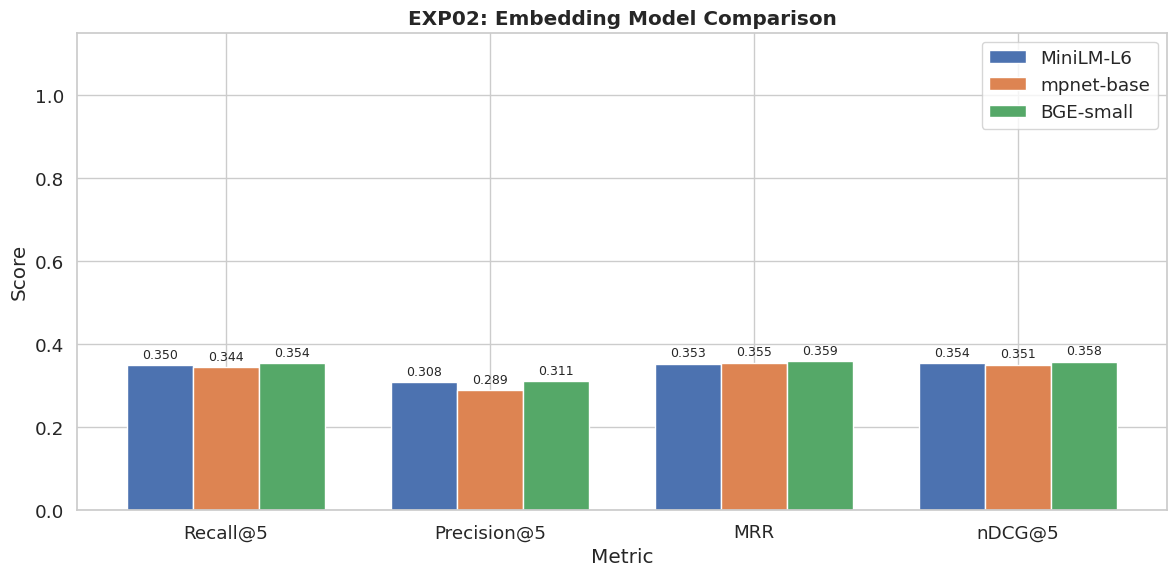

✅ Chart saved: exp02_embedding_metrics.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.2)

metric_cols = ["Recall@5", "Precision@5", "MRR", "nDCG@5"]
models = list(results.keys())

x = np.arange(len(metric_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, model in enumerate(models):
    values = [results[model][m] for m in metric_cols]
    bars = ax.bar(x + i * width, values, width, label=model)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=9,
        )

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("EXP02: Embedding Model Comparison", fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.15)
ax.legend()

plt.tight_layout()
plt.savefig("exp02_embedding_metrics.png", dpi=150)
plt.show()

print("✅ Chart saved: exp02_embedding_metrics.png")

#### 5. Latency VS Accuracy

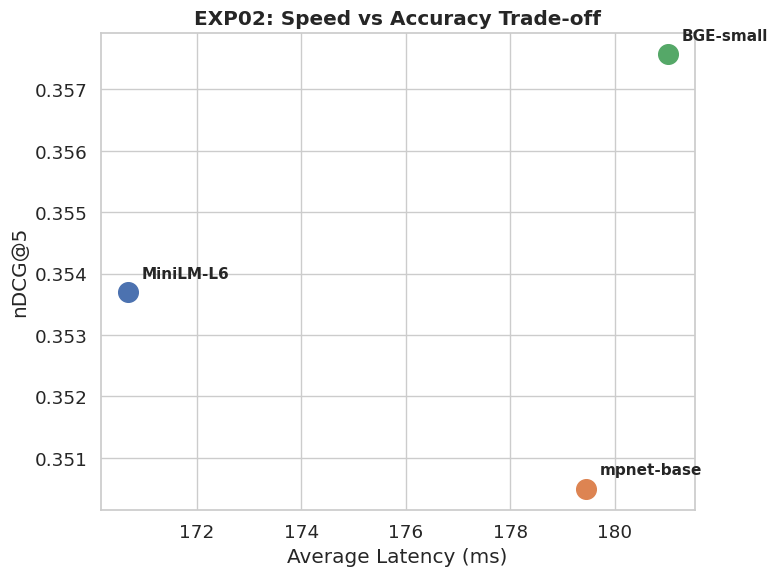

✅ Chart saved: exp02_latency_vs_accuracy.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

for model in models:
    latency = results[model]["Latency (ms)"]
    ndcg = results[model]["nDCG@5"]
    ax.scatter(latency, ndcg, s=200, zorder=5)
    ax.annotate(
        model,
        (latency, ndcg),
        textcoords="offset points",
        xytext=(10, 10),
        fontsize=11,
        fontweight="bold",
    )

ax.set_xlabel("Average Latency (ms)")
ax.set_ylabel("nDCG@5")
ax.set_title("EXP02: Speed vs Accuracy Trade-off", fontweight="bold")

plt.tight_layout()
plt.savefig("exp02_latency_vs_accuracy.png", dpi=150)
plt.show()

print("✅ Chart saved: exp02_latency_vs_accuracy.png")

#### 6. Embedding Time

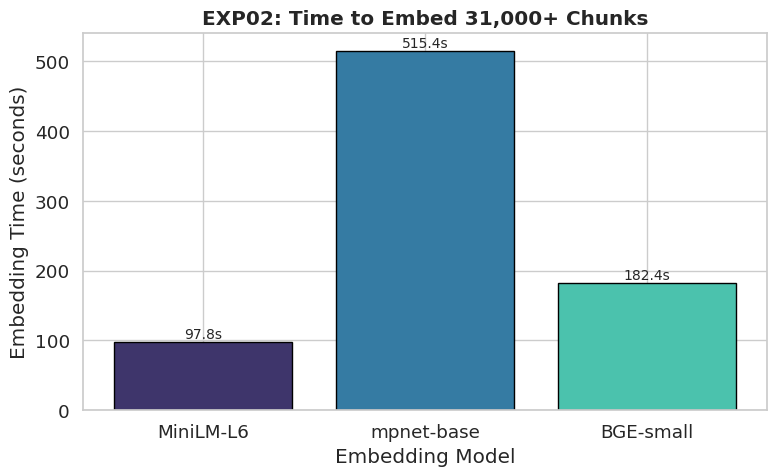

✅ Chart saved: exp02_embed_time.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

embed_times = [results[m]["Embed Time (s)"] for m in models]
colors = sns.color_palette("mako", len(models))

bars = ax.bar(models, embed_times, color=colors, edgecolor="black")

for bar, val in zip(bars, embed_times):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f}s",
        ha="center", va="bottom", fontsize=10,
    )

ax.set_xlabel("Embedding Model")
ax.set_ylabel("Embedding Time (seconds)")
ax.set_title("EXP02: Time to Embed 31,000+ Chunks", fontweight="bold")

plt.tight_layout()
plt.savefig("exp02_embed_time.png", dpi=150)
plt.show()

print("✅ Chart saved: exp02_embed_time.png")